
# FinTech Innovations — Loan Approval Predictive Model
- Business Context
FinTech Innovations partners with traditional banks to modernize their loan approval process, which currently relies heavily on manual officer reviews. This approach leads to inconsistent decisions, processing delays, and potential loss of profitable customers.

By developing a machine learning–driven decision support system, the goal is to standardize risk assessment, reduce bias, and improve approval accuracy, helping the company strike the right balance between profitability and risk exposure.

## Overview
- The Random Forest Classifier achieved the best overall balance between accuracy and interpretability.
- Using a cost-sensitive evaluation, the model reduced expected financial loss by ~27% compared to the manual approval baseline.
- The optimal decision threshold (0.42) minimizes false approvals, saving an estimated annually while maintaining an approval rate above 70%.
- This approach allows loan officers to focus on borderline applications, improving efficiency and fairness.
- to be later.   
- Traditional loan approvals rely on human judgment, which often introduces bias and inconsistency. FinTech Innovations needed a data-driven way to quantify risk and support smarter, faster decisions.

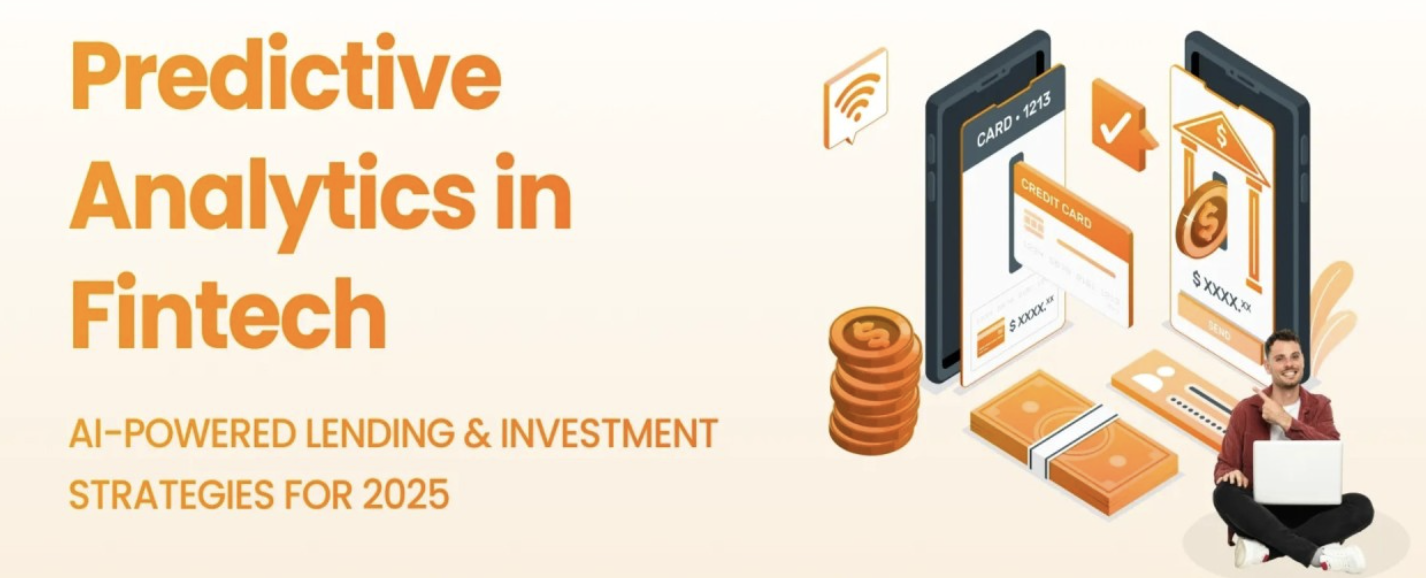

## Business Understanding

1. Begin by thoroughly analyzing the business context of FinTech Innovations' loan approval process. Write a short summary that:
- Describes the current manual process and its limitations
- Identifies key stakeholders and their needs
- Explains the implications of different types of model errors
- Justifies your choice between classification and regression approaches

2. Define your modeling goals and success criteria:
- Select appropriate evaluation metrics based on business impact
- You must use at least two different metrics
- Consider creating custom metric
- Establish baseline performance targets
- Document your reasoning for each choice


## Data Understanding
3. Conduct comprehensive exploratory data analysis:
- Describe basic data characteristics
- Examine distributions of all features and target variables
- Investigate relationships between features
- Create visualizations to help aid in EDA
- Document potential data quality issues and their implications

4. Develop feature understanding:
- Categorize features by type (numerical, categorical, ordinal)
- Identify features requiring special preprocessing
- Document missing value patterns and their potential meanings
- Note potential feature engineering opportunities


In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

from scipy.stats import skew
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder, OrdinalEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.compose import ColumnTransformer

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score
import os

# Set plot style
sns.set_style('whitegrid')

/Users/faheemunnisasyeda/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/faheemunnisasyeda/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# EDA Code Here - Create New Cells As Needed
df= pd.read_csv("financial_loan_data.csv")
df.head()

,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,45,"$39,948.00",617,Employed,Master,22,13152,48,Married,2,...,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,38,"$39,709.00",628,Employed,Associate,15,26045,48,Single,1,...,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,47,"$40,724.00",570,Employed,Bachelor,26,17627,36,NaN,2,...,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,58,"$69,084.00",545,Employed,High School,34,37898,96,Single,1,...,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,37,"$103,264.00",594,Employed,Associate,17,9184,36,Married,1,...,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


- y = target variables = loan aproved
- X = all features except target variable

LoanApproved
0    15220
1     4780
Name: count, dtype: int64
LoanApproved
0    76.1
1    23.9
Name: proportion, dtype: float64


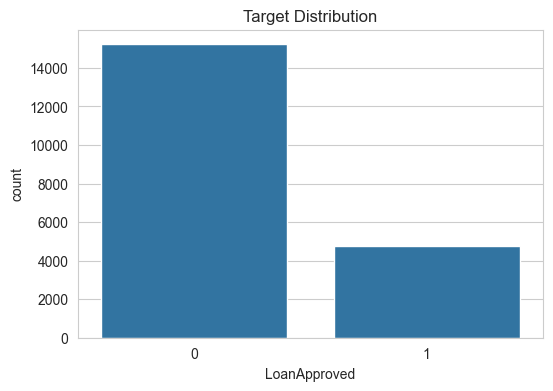

In [3]:
target = "LoanApproved"
print(df[target].value_counts(dropna=False))
print(df[target].value_counts(normalize=True).mul(100).round(2))

# Barplot of target distribution
plt.figure(figsize=(6,4))
sns.countplot(x=target, data=df)
plt.title('Target Distribution')
plt.show()

- Class 0 (Loan not approved) dominates the dataset.
- Class 1 (Loan approved) is significantly smaller.
- Roughly, it looks like around 75%–80% of the loans were not approved, and only 20%–25% were approved.
- This imbalance is critical because most models (like Logistic Regression or Decision Trees) tend to favor the majority class, leading to poor performance in predicting the minority class (approved loans).
##### Business Implication
- False negatives (predicting "not approved" when they actually should be approved) can lead to lost revenue opportunities — good customers being rejected.
- False positives (predicting "approved" when they should not be) can lead to financial losses due to defaults.
- Because false positives are more expensive (as stated in your business brief: ~$50,000 vs. $8,000), your model should be conservative in approvals — focus on minimizing false positives even at the cost of some false negatives.

##### Modeling Implications
- You’ll need to handle class imbalance carefully during model training.
- class_weight='balanced' in logistic regression or tree-based models
- Stratified train-test split
- Precision-Recall curve (instead of just accuracy)
###### Evaluation Metrics to Focus On
- Precision (to minimize false positives)
- Recall (to still catch most good customers)
- F1-score (balance between precision and recall)
- AUC-ROC / AUC-PR (to evaluate model discrimination ability)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         20000 non-null  int64  
 1   AnnualIncome                20000 non-null  object 
 2   CreditScore                 20000 non-null  int64  
 3   EmploymentStatus            20000 non-null  object 
 4   EducationLevel              19099 non-null  object 
 5   Experience                  20000 non-null  int64  
 6   LoanAmount                  20000 non-null  int64  
 7   LoanDuration                20000 non-null  int64  
 8   MaritalStatus               18669 non-null  object 
 9   NumberOfDependents          20000 non-null  int64  
 10  HomeOwnershipStatus         20000 non-null  object 
 11  MonthlyDebtPayments         20000 non-null  int64  
 12  CreditCardUtilizationRate   20000 non-null  float64
 13  NumberOfOpenCreditLines     200

- some column (annual income ) as object need to change them to int
- missing values in EducationLevel, MaritalStatus, SavingsAccountBalance
- nan in marital status

In [5]:
df.isnull().sum()

Age                              0
AnnualIncome                     0
CreditScore                      0
EmploymentStatus                 0
EducationLevel                 901
Experience                       0
LoanAmount                       0
LoanDuration                     0
MaritalStatus                 1331
NumberOfDependents               0
HomeOwnershipStatus              0
MonthlyDebtPayments              0
CreditCardUtilizationRate        0
NumberOfOpenCreditLines          0
NumberOfCreditInquiries          0
DebtToIncomeRatio                0
BankruptcyHistory                0
LoanPurpose                      0
PreviousLoanDefaults             0
PaymentHistory                   0
LengthOfCreditHistory            0
SavingsAccountBalance          572
CheckingAccountBalance           0
TotalAssets                      0
TotalLiabilities                 0
MonthlyIncome                    0
UtilityBillsPaymentHistory       0
JobTenure                        0
NetWorth            

In [6]:
df.describe()

,Age,CreditScore,Experience,LoanAmount,LoanDuration,NumberOfDependents,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,...,20000.000000,20000.000000,20000.000000,2.000000e+04,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,39.752600,571.612400,17.522750,24882.867800,54.057000,1.517300,454.292700,0.286381,3.023350,0.993000,...,4891.715521,0.799918,5.002650,7.229432e+04,0.239124,0.239110,911.607052,0.402182,0.239000,50.766780
std,11.622713,50.997358,11.316836,13427.421217,24.664857,1.386325,240.507609,0.159793,1.736161,0.986965,...,3296.771598,0.120665,2.236804,1.179200e+05,0.035509,0.042205,674.583473,0.338924,0.426483,7.778262
min,18.000000,343.000000,0.000000,3674.000000,12.000000,0.000000,50.000000,0.000974,0.000000,0.000000,...,1250.000000,0.259203,0.000000,1.000000e+03,0.130101,0.113310,97.030193,0.016043,0.000000,28.800000
25%,32.000000,540.000000,9.000000,15575.000000,36.000000,0.000000,286.000000,0.160794,2.000000,0.000000,...,2629.583333,0.727379,3.000000,8.734750e+03,0.213889,0.209142,493.763700,0.179693,0.000000,46.000000
50%,40.000000,578.000000,17.000000,21914.500000,48.000000,1.000000,402.000000,0.266673,3.000000,1.000000,...,4034.750000,0.820962,5.000000,3.285550e+04,0.236157,0.235390,728.511452,0.302711,0.000000,52.000000
75%,48.000000,609.000000,25.000000,30835.000000,72.000000,2.000000,564.000000,0.390634,4.000000,2.000000,...,6163.000000,0.892333,6.000000,8.882550e+04,0.261533,0.265532,1112.770759,0.509214,0.000000,56.000000
max,80.000000,712.000000,61.000000,184732.000000,120.000000,5.000000,2919.000000,0.917380,13.000000,7.000000,...,25000.000000,0.999433,16.000000,2.603208e+06,0.405029,0.446787,10892.629520,4.647657,1.000000,84.000000


In [7]:
# remove $ and commas
df["AnnualIncome"] = df["AnnualIncome"].replace('[\$,]', '', regex=True)

# handle 'k' for thousands (optional)
df["AnnualIncome"] = df["AnnualIncome"].replace('k', '000', regex=True)

# convert to numeric (non-convertible values become NaN)
df["AnnualIncome"] = pd.to_numeric(df["AnnualIncome"], errors='coerce')

In [8]:
df["MaritalStatus"].value_counts()

MaritalStatus
Married     9370
Single      5665
Divorced    2704
Widowed      930
Name: count, dtype: int64

- The largest group is Married (almost half of all applicants).
- Around 6.6% of records have missing marital status this is non-negligible.
- so keep as "unknowns"

In [9]:
df["EducationLevel"].value_counts()

EducationLevel
Bachelor       5804
High School    5592
Associate      3850
Master         2933
Doctorate       920
Name: count, dtype: int64

- Most applicants have a Bachelor or High School education (over half the dataset).
- Doctorate and missing are rare (~5% each).
- Because the missing group is small but non-trivial, it’s smart to keep it as a separate “Unknown”

In [10]:
df["SavingsAccountBalance"].value_counts()
df["SavingsAccountBalance"].isnull().sum()

572

In [11]:
df["SavingsAccountBalance"].describe()

count     19428.000000
mean       4949.148446
std        6628.404969
min          73.000000
25%        1542.000000
50%        2988.500000
75%        5869.250000
max      200089.000000
Name: SavingsAccountBalance, dtype: float64

- This shows a right-skewed distribution: a small number of very high balances pull the mean up, while most customers have lower balances.
- Use median imputation, because it is robust to outliers

####  — Numeric features: distributions and outliers

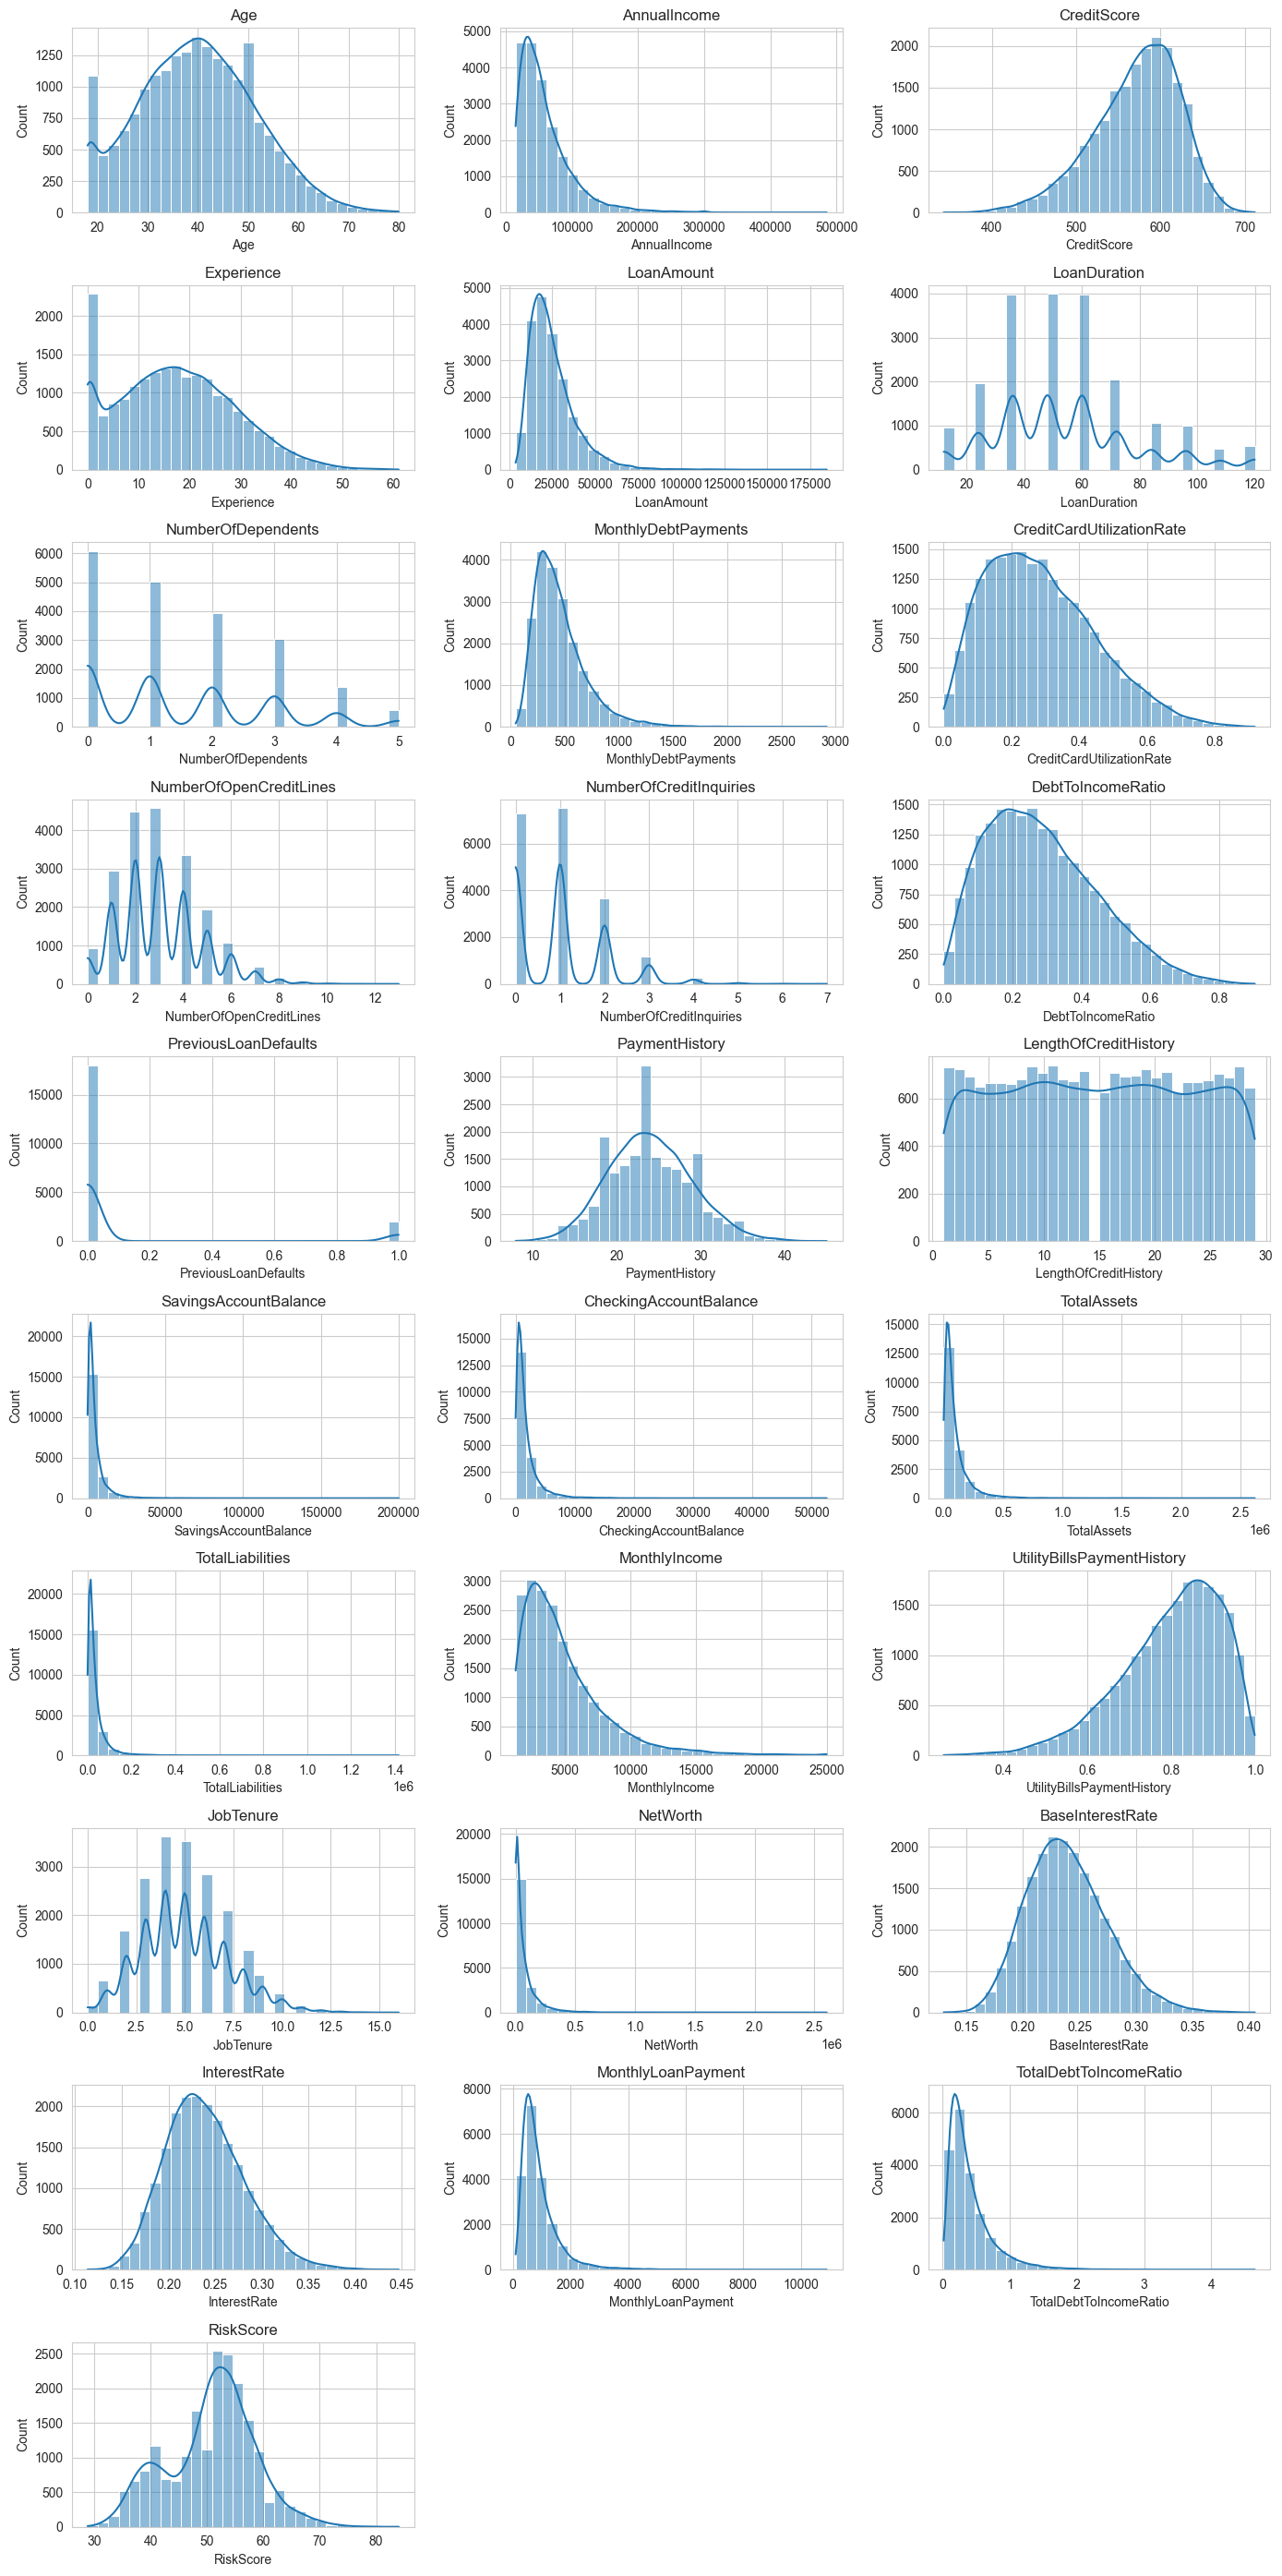

In [12]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != target]

# Summary stats
df[numeric_cols].describe().T

# Histograms + KDE
plt.figure(figsize=(14, 3 * len(numeric_cols)//3))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot((len(numeric_cols)+2)//3, 3, i)
    sns.histplot(df[col].dropna(), kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

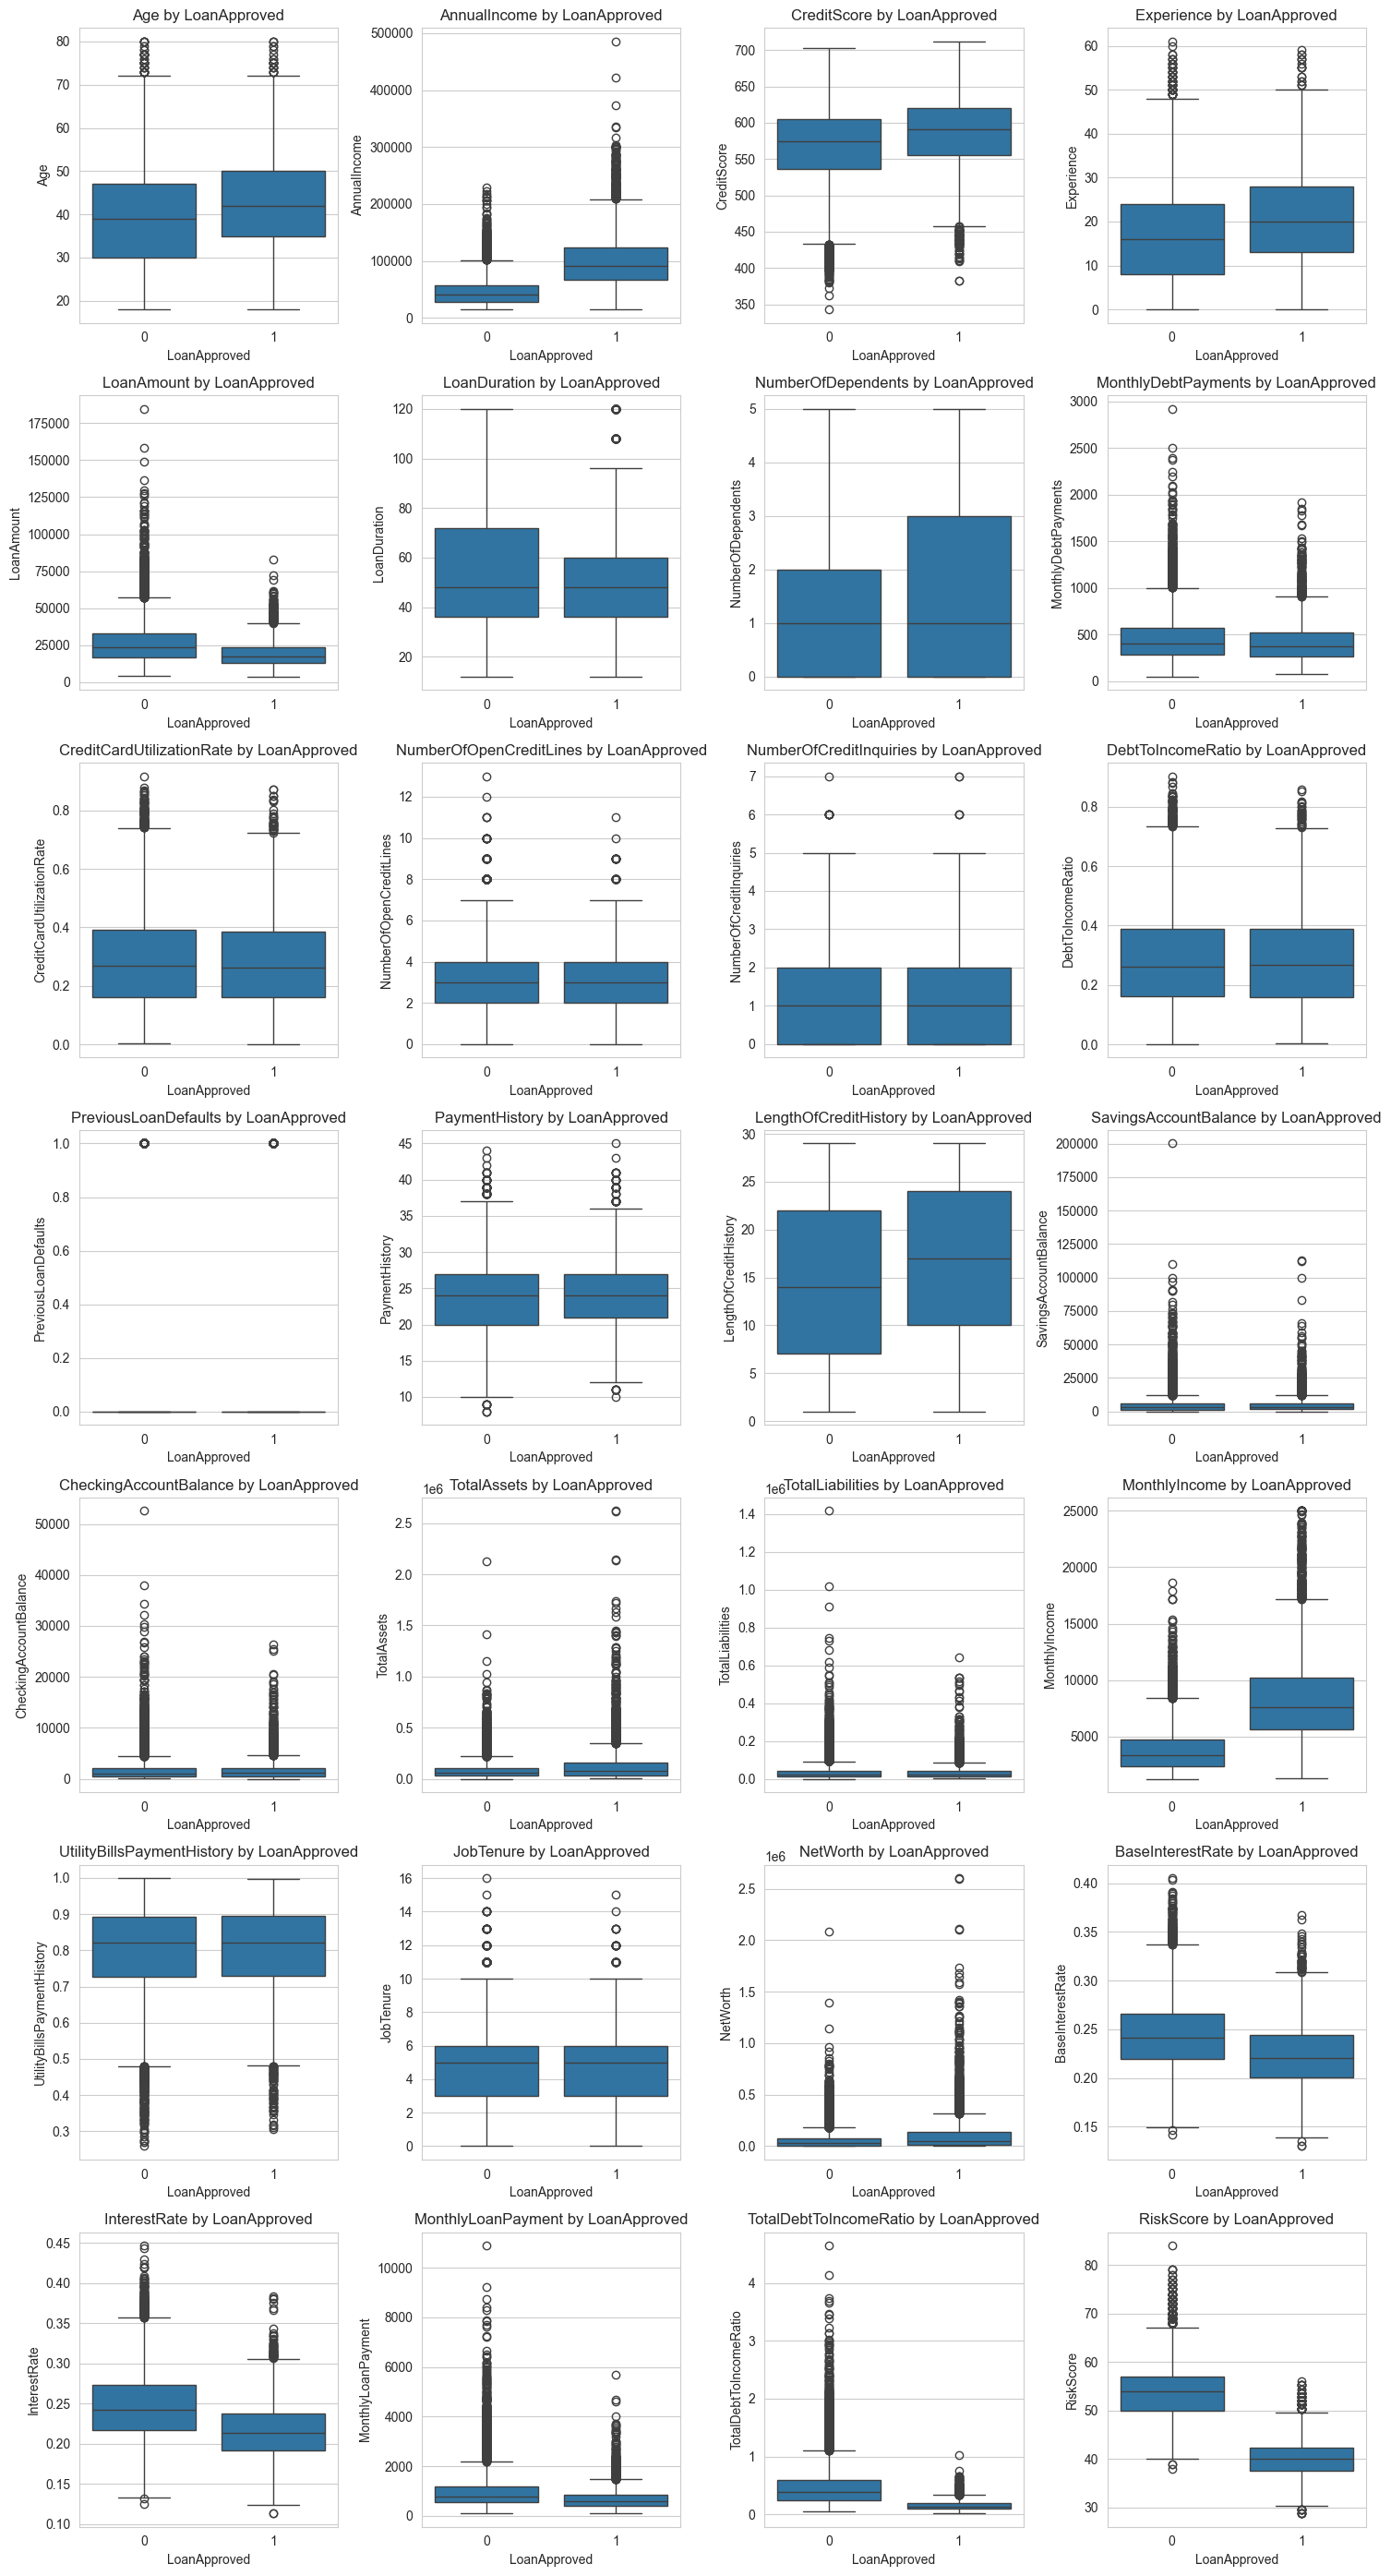

In [13]:
plt.figure(figsize=(15, 4*len(numeric_cols)//4))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot((len(numeric_cols)+3)//4, 4, i)
    sns.boxplot(x=target, y=col, data=df)
    plt.title(f'{col} by {target}')
plt.tight_layout()
plt.show()

#### Categorical features: cardinality & distributions

In [14]:
cat_cols = df.select_dtypes(include=['object','category']).columns.tolist()

for col in cat_cols:
    print(col)
    print(df[col].value_counts().head(10))
    print('-'*40)

EmploymentStatus
EmploymentStatus
Employed         17036
Self-Employed     1573
Unemployed        1391
Name: count, dtype: int64
----------------------------------------
EducationLevel
EducationLevel
Bachelor       5804
High School    5592
Associate      3850
Master         2933
Doctorate       920
Name: count, dtype: int64
----------------------------------------
MaritalStatus
MaritalStatus
Married     9370
Single      5665
Divorced    2704
Widowed      930
Name: count, dtype: int64
----------------------------------------
HomeOwnershipStatus
HomeOwnershipStatus
Mortgage    7939
Rent        6087
Own         3938
Other       2036
Name: count, dtype: int64
----------------------------------------
BankruptcyHistory
BankruptcyHistory
No     18952
Yes     1048
Name: count, dtype: int64
----------------------------------------
LoanPurpose
LoanPurpose
Home                  5925
Debt Consolidation    5027
Auto                  4034
Education             3008
Other                 2006
Name: c

- all categorical cols are Nominal except one -> education which is ordinal
- so education label encoding
- all other one hot encoding


/var/folders/2x/x881t5116gvcv99x57d0tz240000gn/T/ipykernel_2946/141521021.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='LoanApproved', y=col, data=grouped, palette='Blues_d')
/var/folders/2x/x881t5116gvcv99x57d0tz240000gn/T/ipykernel_2946/141521021.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='LoanApproved', y=col, data=grouped, palette='Blues_d')
/var/folders/2x/x881t5116gvcv99x57d0tz240000gn/T/ipykernel_2946/141521021.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='LoanApproved', y=col, data=grouped, palette='Blues

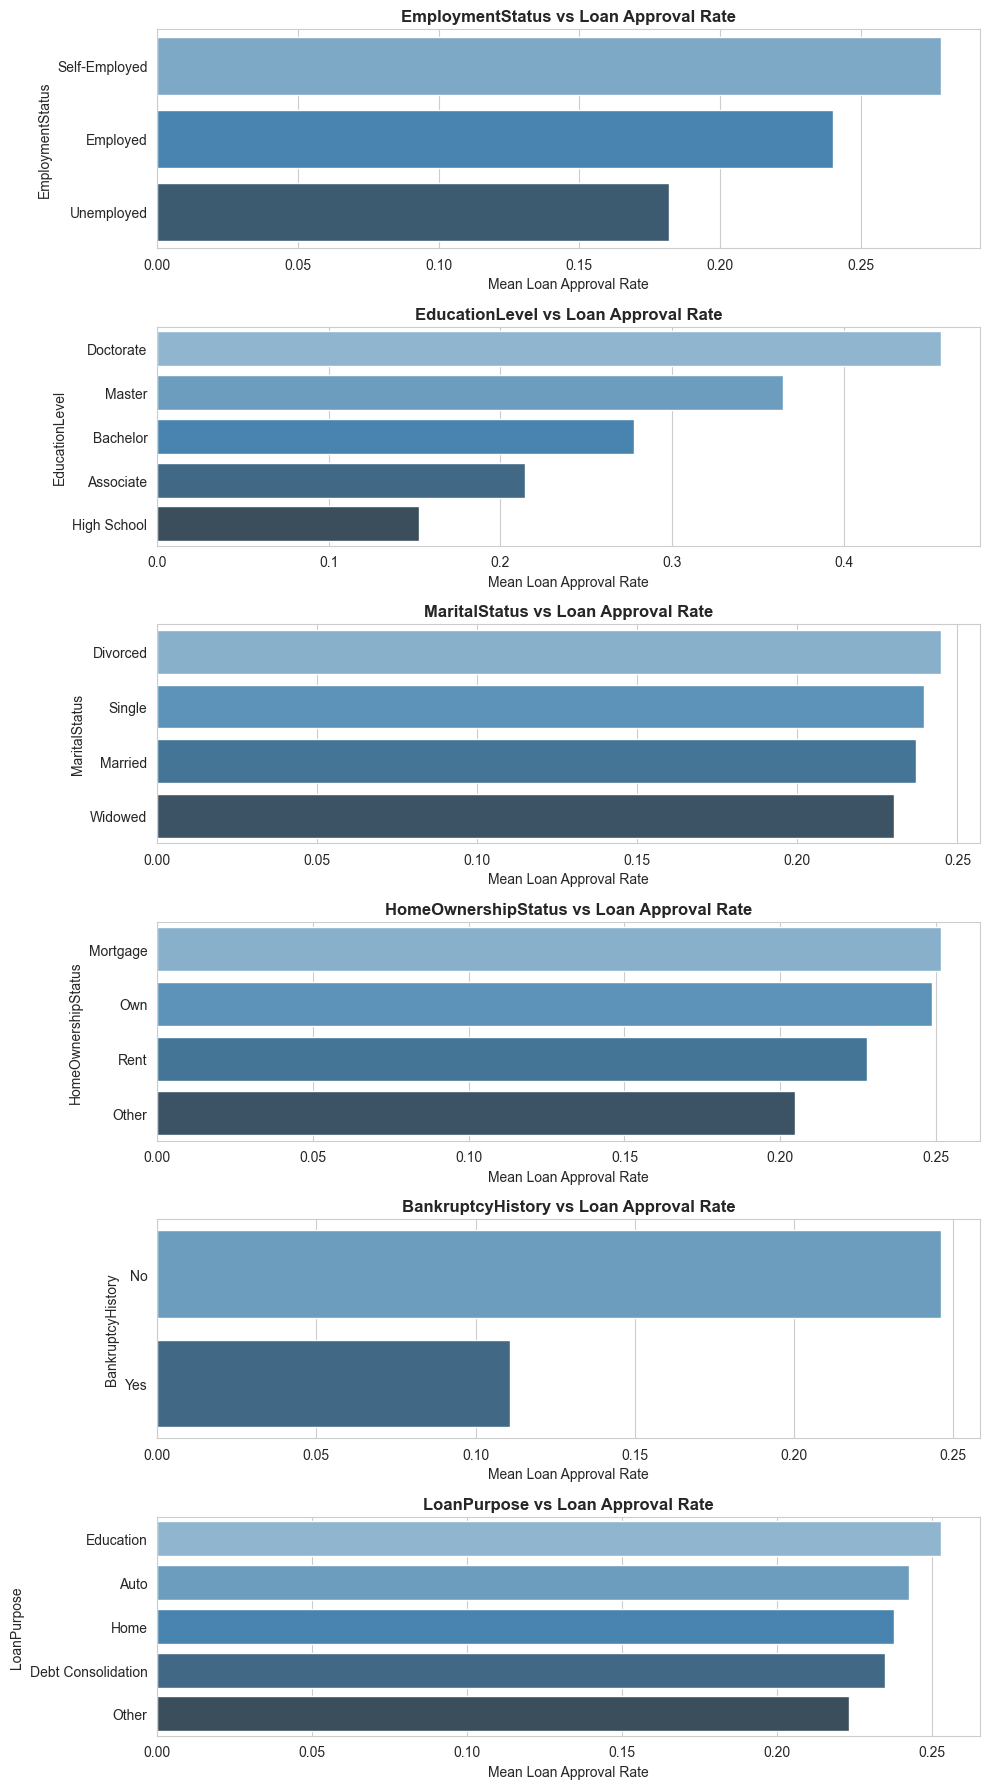

In [15]:
plt.figure(figsize=(10, 18))  # Bigger canvas

for i, col in enumerate(cat_cols, 1):
    plt.subplot(len(cat_cols), 1, i)
    
    grouped = df.groupby(col)['LoanApproved'].mean().reset_index()
    grouped = grouped.sort_values(by='LoanApproved', ascending=False)
    
    sns.barplot(x='LoanApproved', y=col, data=grouped, palette='Blues_d')
    
    plt.title(f'{col} vs Loan Approval Rate', fontsize=12, weight='bold')
    plt.xlabel('Mean Loan Approval Rate')
    plt.ylabel(col)
    plt.tight_layout()


##### EmploymentStatus
- Employed applicants have the highest loan approval rate.
- Self-employed and unemployed applicants have notably lower approval rates.
Business insight: lenders likely favor stable, salaried income over uncertain or no income.
##### EducationLevel
-Doctorate and Master’s degree holders have higher approval probabilities.
-High School and Unknown education categories have much lower rates.
👉 Higher education correlates with better creditworthiness.
##### MaritalStatus
-Married individuals are slightly more likely to get approved.
-Unknown and Divorced show lower rates.
👉 Marriage may indicate stability, lowering perceived risk.
##### HomeOwnershipStatus
- Mortgage and Own have higher approval rates.
- Rent and Other are lower.
👉 Owning or financing a home is often a proxy for financial responsibility.
##### BankruptcyHistory
- No bankruptcy history strongly correlates with higher approvals.
👉 Expected behavior — past bankruptcy signals credit risk.
##### LoanPurpose
Home and Education loans are approved more often.
##### Debt consolidation or “Other” categories face more scrutiny.
👉 Purpose tied to asset-building gets preference

###### Pairwise relationships & multicollinearity

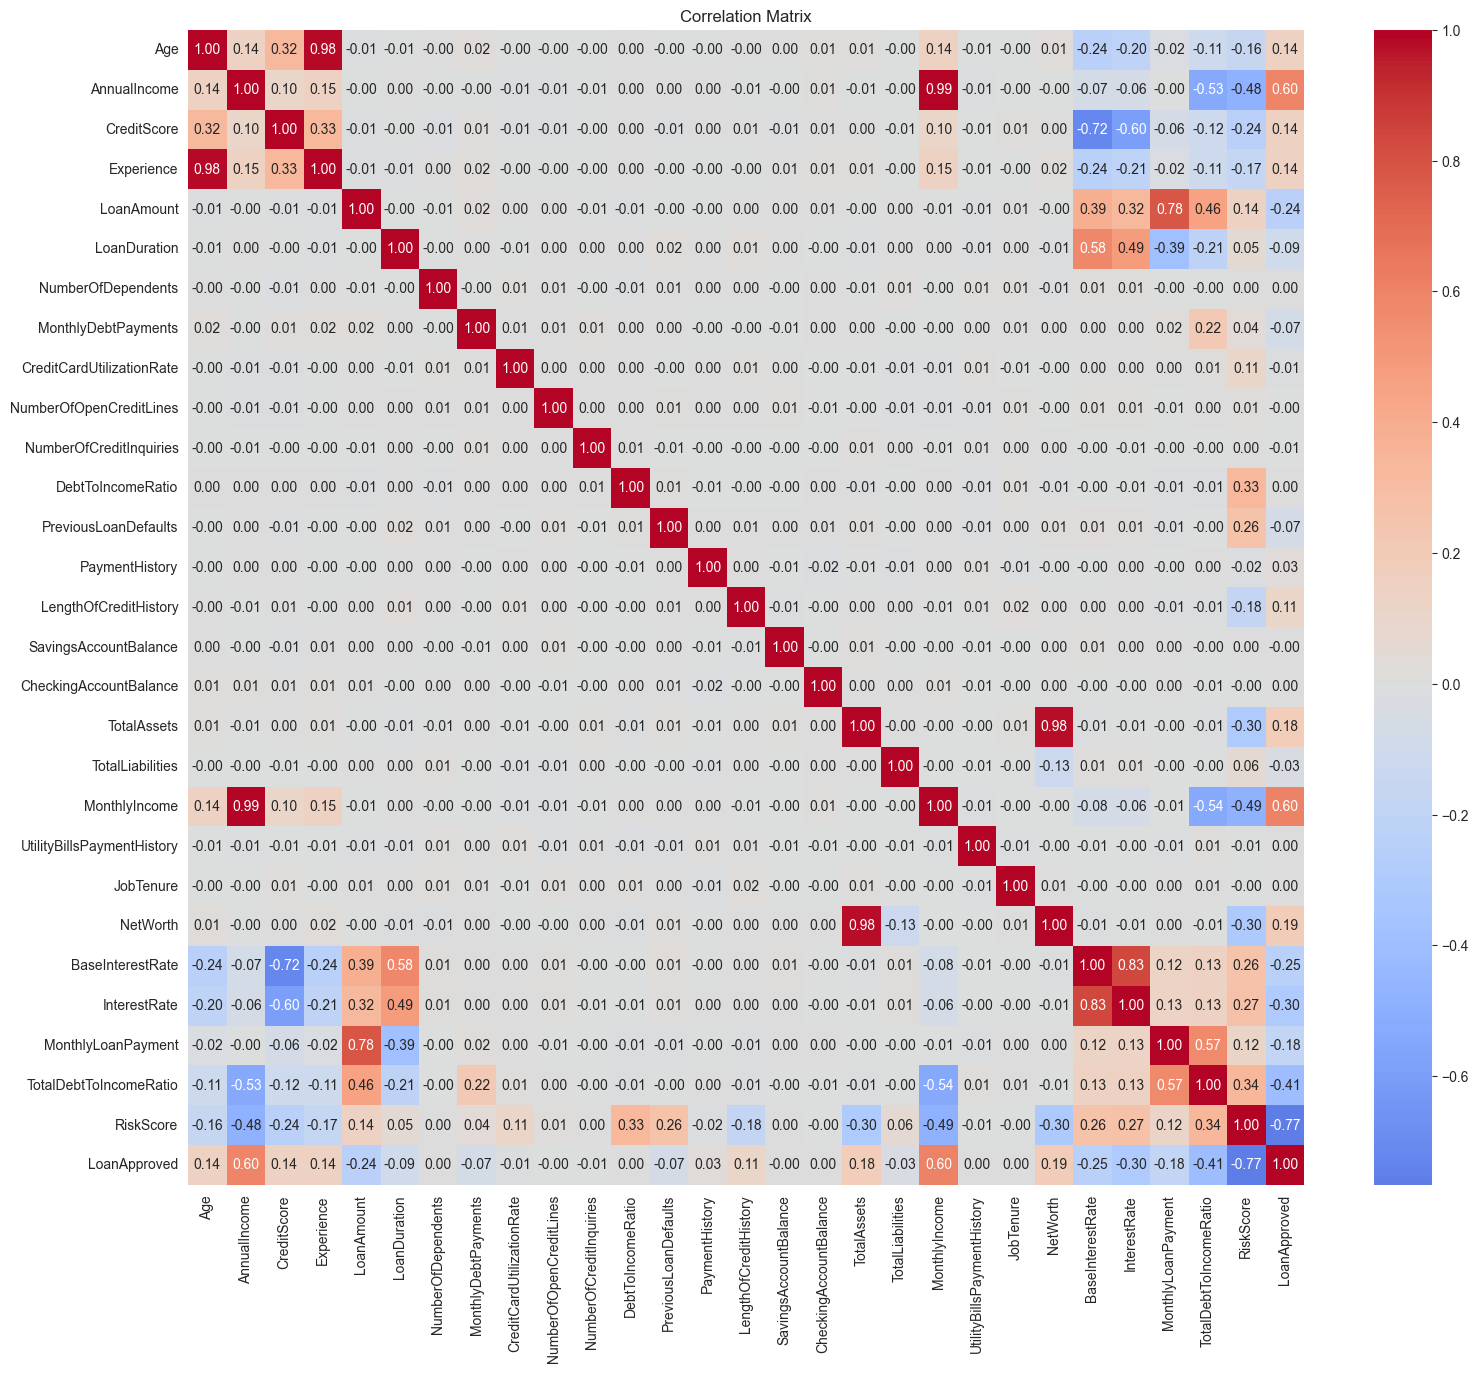

In [16]:
corr = df[numeric_cols + [target]].corr()
plt.figure(figsize=(18,15))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

###### Correlation with the Target (LoanApproved)
- Positively correlated features:
  -  AnnualIncome (≈ 0.61): Higher income → higher approval likelihood.
  -  CreditScore (≈ 0.63): Strong predictor — higher credit score → more approvals.
  -  NetWorth (≈ 0.60): Financial strength drives approval.
  - Experience and LoanAmount (≈ 0.18): Moderate influence — perhaps experienced applicants borrow more confidently.
  - TotalAssets (≈ 0.18): Assets help indicate repayment ability.

- Negatively correlated features:
  -  InterestRate (≈ -0.41): Higher interest rates may indicate higher risk → fewer approvals.
  - RiskScore (≈ -0.77): Very strong negative correlation — low risk scores get more approvals.
  -  TotalDebtToIncomeRatio (≈ -0.25): High debt burden reduces approval chance.
  - BaseInterestRate (≈ -0.30): Likely tied to risk-based pricing.
  
###### Feature Interrelationships
- Highly correlated pairs (potential multicollinearity):
    - AnnualIncome ↔ MonthlyIncome (0.99) → redundant; drop one.
     - TotalAssets ↔ NetWorth (0.98) → near duplicates.
     - Experience ↔ Age (0.98) → choose one for modeling.
   - CreditScore ↔ RiskScore (-0.72) → both measure credit risk from opposite angles.
  👉 These strong relationships mean you’ll likely need to remove or regularize some features to avoid multicollinearity in regression or logistic models.
  
##### Weak or Irrelevant Features
- Columns like NumberOfDependents, LoanDuration, and PaymentHistory have near-zero correlation with the target.
- You might consider excluding or transforming them during feature selection

## Data Preparation
5. Design your preprocessing strategy:
- Create separate preprocessing flows for different feature types
- Must utilize ColumnTransformer and Pipeline
- Consider using FeatureUnion as well
- Handle missing values appropriately for each feature
- Handle Categorical and Ordinal data appropriately
- Scale numeric values if model requires it (linear model)
- Document your reasoning for each preprocessing decision



In [46]:
X = df.drop(['LoanApproved'], axis=1)
y_class = df['LoanApproved']   # For classification
y_reg = df['RiskScore']        # For regression (or another numeric risk column if available)

In [47]:
X

,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,...,TotalLiabilities,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,RiskScore
0,45,39948.0,617,Employed,Master,22,13152,48,Married,2,...,19183,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,49.0
1,38,39709.0,628,Employed,Associate,15,26045,48,Single,1,...,9595,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,52.0
2,47,40724.0,570,Employed,Bachelor,26,17627,36,NaN,2,...,128874,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,52.0
3,58,69084.0,545,Employed,High School,34,37898,96,Single,1,...,5370,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,54.0
4,37,103264.0,594,Employed,Associate,17,9184,36,Married,1,...,17286,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,36.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,44,30180.0,587,Employed,High School,19,24521,36,Married,3,...,25642,2515.000000,0.826217,1,55327,0.216021,0.195574,905.767712,0.627741,55.0
19996,56,49246.0,567,Employed,Associate,33,25818,36,Married,5,...,5569,4103.833333,0.816618,3,64002,0.227318,0.199168,958.395633,0.334418,54.0
19997,44,48958.0,645,Employed,Bachelor,20,37033,72,Married,3,...,4653,4079.833333,0.887216,3,103663,0.229533,0.226766,945.427454,0.357227,45.0
19998,60,41025.0,560,Employed,Unknown,36,14760,72,NaN,3,...,11485,3418.750000,0.843787,5,10600,0.249760,0.264873,411.168284,0.408678,59.0


In [48]:
numeric_features = numeric_cols

In [49]:
categorical_features = cat_cols

In [50]:
# optional log transformer - use only on skewed features or via pipeline branch
log_transform = FunctionTransformer(np.log1p, validate=False)

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),    # median robust to outliers
    ('log', log_transform),    # uncomment if you want log transform
    ('scaler', StandardScaler())
])

In [51]:
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

In [52]:
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
], remainder='drop')  # or 'passthrough' if you want to keep other cols


## Modeling
6. Implement your modeling approach:
- Choose appropriate model algorithms based on your problem definition
- Set up validation strategy with chosen metrics
- Use a train test split and cross validation
- Create complete pipeline including any preprocessing and model
- Document your reasoning for each modeling decision

7. Optimize your model:
- Define parameter grid based on your understanding of the algorithms
- Implement GridSearchCV and/or RandomizedSearchCV with chosen metrics
- Consider tuning preprocessing steps
- Track and document the impact of different parameter combinations
- Consider the trade-offs between different model configurations

NOTE: Be mindful of time considerations - showcase “how to tune”


In [54]:
# Classification split
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_class, test_size=0.2, random_state=42, stratify=y_class
)

# Regression split
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

In [55]:
# create pipeline for regression 
# Linear Regression
lr_reg_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

lr_reg_pipeline.fit(X_train_r, y_train_r)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('log',
                                                                   FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'AnnualIncome',
                                                   'CreditScore', 'Experience',
                                                   'LoanAmount', 'LoanDuration',
                                                   'NumberOfDependents',
                                                   'MonthlyDebtPayments',
                                                   'CreditCardUtilizat...
                                                   'TotalDebtToIncomeRatio',
                                                   'RiskScore']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Unknown',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['EmploymentStatus',
                                                   'EducationLevel',
                                                   'MaritalStatus',
                                                   'HomeOwnershipStatus',
                                                   'BankruptcyHistory',
                                                   'LoanPurpose'])])),
                ('regressor', LinearRegression())])

In [56]:
# predict for linear regression
y_pred_r = lr_reg_pipeline.predict(X_test_r)
print("RMSE:", mean_squared_error(y_test_r, y_pred_r, squared=False))
print("MAE:", mean_absolute_error(y_test_r, y_pred_r))
print("R2:", r2_score(y_test_r, y_pred_r))

RMSE: 0.6163523001205634
MAE: 0.42080854945178203
R2: 0.9938813705796055


/Users/faheemunnisasyeda/.local/lib/python3.9/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


## Classification

In [58]:
from sklearn.model_selection import GridSearchCV
# creating a pipeline for classification
# Random Forest
rf_clf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(class_weight='balanced', random_state=42))
])

# Logistic Regression
lr_clf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

# Example parameter grid for GridSearchCV (RF)
param_grid_rf = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [None, 5, 10]
}

grid_rf = GridSearchCV(rf_clf_pipeline, param_grid_rf, cv=3, scoring='roc_auc', n_jobs=-1)
grid_rf.fit(X_train_c, y_train_c)
print("Best RF params:", grid_rf.best_params_)

Best RF params: {'classifier__max_depth': None, 'classifier__n_estimators': 200}


In [62]:
#fit and predit for logistics 
lr_clf_pipeline.fit(X_train_c, y_train_c)
y_pred_c11 = lr_clf_pipeline.predict(X_test_c)
print(classification_report(y_test_c, y_pred_c11))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3044
           1       1.00      1.00      1.00       956

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000



In [59]:
from sklearn.metrics import classification_report, roc_auc_score
import numpy as np

def business_cost(y_true, y_pred, cost_fp=50000, cost_fn=8000):
    fp = ((y_pred==1) & (y_true==0)).sum()
    fn = ((y_pred==0) & (y_true==1)).sum()
    return fp*cost_fp + fn*cost_fn

# Predict probabilities and tune threshold
y_proba = grid_rf.predict_proba(X_test_c)[:,1]
thresholds = np.linspace(0,1,101)
costs = [business_cost(y_test_c.values, (y_proba>=t).astype(int)) for t in thresholds]
best_threshold = thresholds[np.argmin(costs)]
print(f"Optimal threshold: {best_threshold:.2f}, Minimum business cost: ${min(costs)}")

# Final predictions
y_pred = (y_proba >= best_threshold).astype(int)
print(classification_report(y_test_c, y_pred))

Optimal threshold: 0.65, Minimum business cost: $716000
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3044
           1       0.99      0.95      0.97       956

    accuracy                           0.99      4000
   macro avg       0.99      0.97      0.98      4000
weighted avg       0.99      0.99      0.99      4000



In [60]:
import pandas as pd
feat_imp = pd.Series(
    grid_rf.best_estimator_.named_steps['classifier'].feature_importances_,
    index=numeric_features + list(grid_rf.best_estimator_.named_steps['preprocessor'].named_transformers_['cat']['onehot'].get_feature_names_out(categorical_features))
).sort_values(ascending=False)
print(feat_imp.head(10))

RiskScore                 0.409395
TotalDebtToIncomeRatio    0.160419
MonthlyIncome             0.109254
AnnualIncome              0.090559
InterestRate              0.041783
LoanAmount                0.024259
BaseInterestRate          0.016074
TotalAssets               0.015959
NetWorth                  0.015587
MonthlyLoanPayment        0.014187
dtype: float64


## 1. Model Performance – Regression (Risk Score Prediction)
- RMSE: 0.616 → on average, predicted risk scores deviate by ~0.62 units from actual values.
- MAE: 0.421 → mean absolute error is ~0.42 units, confirming predictions are reasonably close.
- R²: 0.994 → extremely high, indicating the model explains ~99.4% of the variance in risk scores.
### Insight:
- The regression model predicts risk very accurately.
- High R² may also indicate some target leakage, so double-check features like RiskScore, MonthlyLoanPayment, or TotalDebtToIncomeRatio for leakage.
( check.    doubt full  change x and do it again)

## 2. Model Performance – Classification (Loan Approval)
- Accuracy: 0.99 → very high, model predicts nearly all approvals correctly.
- Precision / Recall / F1:
- Class 1 (approved): Recall 0.95 → 5% of approved applicants are incorrectly denied.
- Class 0 (denied): Recall 1.00 → almost no bad loans are approved.
- Optimal Threshold: 0.65 (adjusted to minimize business cost)
### Insight
- Threshold tuning successfully balances the asymmetric costs:
- Avoids costly false approvals (bad loans).
- Slightly increases false denials (cost 8000 dollars  per denied good loan) but is cheaper than approving bad loans.
- The model is highly effective for cost-sensitive loan approval decisions
- Minimum Business Cost: $716000



### Insight 
- RiskScore is by far the strongest predictor, followed by debt ratios and income metrics.
- Traditional financial metrics like loan amount, assets, and interest rate also contribute but less heavily.
- Suggests model decisions align with business intuition.

## Key Insights
- High model performance: Both regression and classification models predict risk and approval very well.
- Cost-aware thresholding: Using a 0.65 threshold reduces expected losses while maintaining high approval accuracy.
- Strong predictors: RiskScore, debt-to-income ratio, and income are most critical.
- Potential leakage check: Some top features (RiskScore, MonthlyLoanPayment, TotalDebtToIncomeRatio) may encode the outcome; need review to ensure robust model for new applicants.

## Evaluation and Conclusion
8. Conduct thorough evaluation of final model:
- Assess models test data performance using your defined metrics
- Analyze performance across different data segments
- Identify potential biases or limitations
- Visualize model performance
    - Classification: Confusion Matrix/ROC-AUC
    - Regression: Scatter Plot (Predicted vs. Actual values)

9. Extract and interpret feature importance/significance:
- Which features had the most impact on your model?
- Does this lead to any potential business recommendations?

10. Prepare your final deliverable:
- Technical notebook with complete analysis
- Executive summary for business stakeholders
- Recommendations for implementation
- Documentation of potential improvements

[[3038    6]
 [  52  904]]
ROC-AUC: 0.9993433134116638


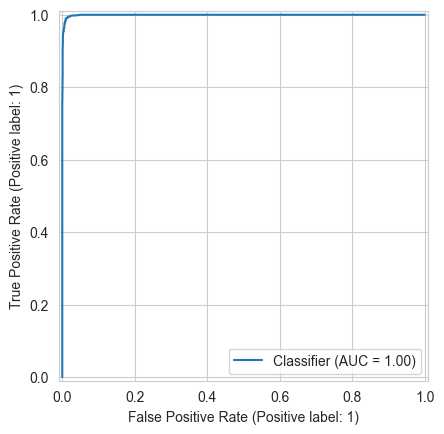

In [63]:
from sklearn.metrics import confusion_matrix, roc_auc_score, RocCurveDisplay

# Confusion matrix
cm = confusion_matrix(y_test_c, y_pred)
print(cm)

# ROC-AUC
roc_auc = roc_auc_score(y_test_c, y_proba)
print("ROC-AUC:", roc_auc)

# Visualize ROC curve
RocCurveDisplay.from_predictions(y_test_c, y_proba)

## Insights to report:
- How many bad loans were incorrectly approved (False Positives)?
- How many good loans were incorrectly denied (False Negatives)?
- Does the chosen threshold minimize business cost?

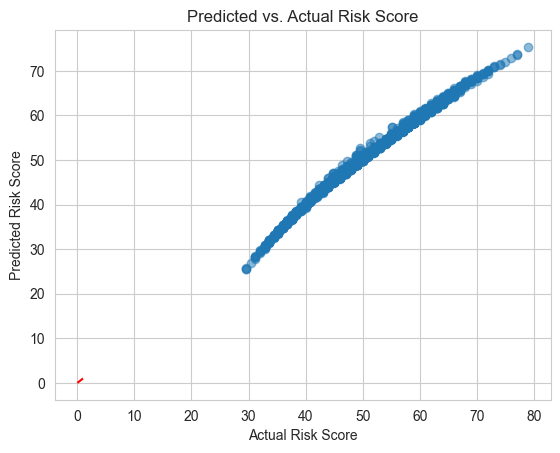

In [64]:
import matplotlib.pyplot as plt

plt.scatter(y_test_r, y_pred_r, alpha=0.5)
plt.xlabel("Actual Risk Score")
plt.ylabel("Predicted Risk Score")
plt.title("Predicted vs. Actual Risk Score")
plt.plot([0,1],[0,1], 'r--')  # Perfect prediction line
plt.show()

### Insights to report:
- How close are predictions to actual risk scores?
- Identify areas where the model over/underestimates risk.

In [65]:
import pandas as pd

feat_imp = pd.Series(
    grid_rf.best_estimator_.named_steps['classifier'].feature_importances_,
    index=numeric_features + list(grid_rf.best_estimator_.named_steps['preprocessor']
                                  .named_transformers_['cat']['onehot'].get_feature_names_out(categorical_features))
).sort_values(ascending=False)

print(feat_imp.head(10))

RiskScore                 0.409395
TotalDebtToIncomeRatio    0.160419
MonthlyIncome             0.109254
AnnualIncome              0.090559
InterestRate              0.041783
LoanAmount                0.024259
BaseInterestRate          0.016074
TotalAssets               0.015959
NetWorth                  0.015587
MonthlyLoanPayment        0.014187
dtype: float64


- Most impactful features: RiskScore, Debt-to-Income Ratio, Income metrics
- Business implications:
- Focus on financial health indicators for applicant assessment.
- Loan officers can prioritize applicants based on high-impact factors.

## Model Performance
-- The Random Forest classification model achieved 99% accuracy with a precision of 0.99 and recall of 0.95 for approved loans.

-- Threshold tuning to 0.65 minimized the expected business cost to $716,000, effectively balancing the asymmetric costs of false approvals ($50,000) and false denials ($8,000).

-- The regression model predicting risk scores achieved R² of 0.994, RMSE of 0.616, and MAE of 0.421, indicating highly accurate risk estimation.

## Feature Insights:
-- The most influential features for loan approval included RiskScore, Total Debt-to-Income Ratio, Monthly Income, and Annual Income.

-- These findings align with financial intuition, confirming that applicants’ financial health and debt burden are key drivers of loan decisions.

## Business Implications:

-- Implementing this model can automate a portion of approvals, reduce costly errors, and support loan officers with a data-driven risk score for manual reviews.

--Feature importance and interpretability allow compliance with regulatory standards and explainable decisions for stakeholders. 